# Classification — Diabetes Risk Prediction

## Machine Learning Capstone Project

This notebook presents the complete classification workflow for the Diabetes Risk Prediction dataset.

The workflow covers:

- Dataset loading and initial audit
- Exploratory Data Analysis (EDA)
- Data cleaning
- Encoding and feature scaling
- Train-test splitting
- Feature engineering
- Classification model implementation
- Model evaluation
- Preliminary model comparison

The analysis is structured according to the Review 1 requirements of the ML-301 Machine Learning Capstone.

# A. Dataset & EDA

## A1. Dataset Loading and Audit

Before performing any preprocessing or model training, the dataset is loaded and examined to understand its structure, feature types, missing values, duplicate records, and target variable.

The dataset audit is performed before cleaning so that the original data-quality issues can be clearly identified and documented.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

GLOBAL_SEED = 42

sns.set_theme(
    style="whitegrid",
    palette="colorblind"
)

In [2]:
# Load dataset

DATA_PATH = "../data/diabetes_risk_prediction_dataset.csv"

df = pd.read_csv(DATA_PATH)

TARGET = "Diabetes_Risk"

# Dataset shape
print("========== DATASET SHAPE ==========")
print("Rows    :", df.shape[0])
print("Columns :", df.shape[1])

# Data types
print("\n========== DATA TYPES ==========")
display(df.dtypes.to_frame("Data Type"))

# Missing values
print("\n========== MISSING VALUES ==========")

missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (
        df.isnull().sum() / len(df) * 100
    ).round(2)
})

display(missing)

# Target distribution
print("\n========== TARGET DISTRIBUTION ==========")
print("Target Variable:", TARGET)

display(
    df[TARGET]
    .value_counts(dropna=False)
    .to_frame("Count")
)

print("\nTarget Distribution (%):")

display(
    (
        df[TARGET]
        .value_counts(normalize=True, dropna=False) * 100
    )
    .round(2)
    .to_frame("Percentage")
)

========== DATASET SHAPE ==========
Rows    : 50000
Columns : 42

========== DATA TYPES ==========


,Data Type
Patient_ID,int64
Age,float64
Gender,str
Country,str
Height_cm,float64
Weight_kg,float64
BMI,float64
Waist_Circumference_cm,float64
Blood_Glucose,float64
HbA1c,float64



========== MISSING VALUES ==========


,Missing Count,Missing Percentage
Patient_ID,0,0.00
Age,497,0.99
Gender,0,0.00
Country,0,0.00
Height_cm,2945,5.89
Weight_kg,2962,5.92
BMI,0,0.00
Waist_Circumference_cm,0,0.00
Blood_Glucose,959,1.92
HbA1c,1974,3.95



========== TARGET DISTRIBUTION ==========
Target Variable: Diabetes_Risk


,Count
Diabetes_Risk,
High,36593
Moderate,12937
Low,470



Target Distribution (%):


,Percentage
Diabetes_Risk,
High,73.19
Moderate,25.87
Low,0.94


## A2. Exploratory Data Analysis

The dataset is explored using target distribution, feature distributions, correlation analysis, and feature-target relationships to identify important patterns and characteristics in the data.

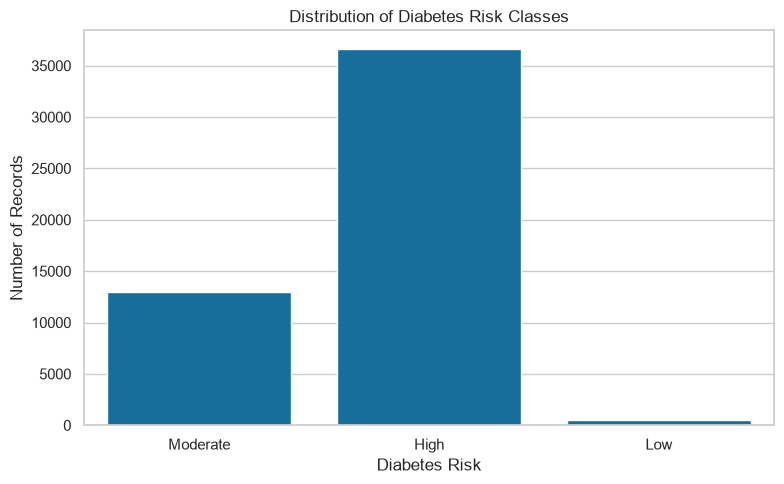

In [3]:
# Target distribution

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x=TARGET
)

plt.title("Distribution of Diabetes Risk Classes")
plt.xlabel("Diabetes Risk")
plt.ylabel("Number of Records")

plt.tight_layout()
plt.show()

### Observation

The target variable `Diabetes_Risk` is highly imbalanced across the three classes. The `High` risk class contains the largest number of records, followed by the `Moderate` class, while the `Low` risk class has comparatively very few observations. This class imbalance should be considered when evaluating the classification models, particularly when comparing accuracy with weighted F1-score.

Number of numerical features: 21


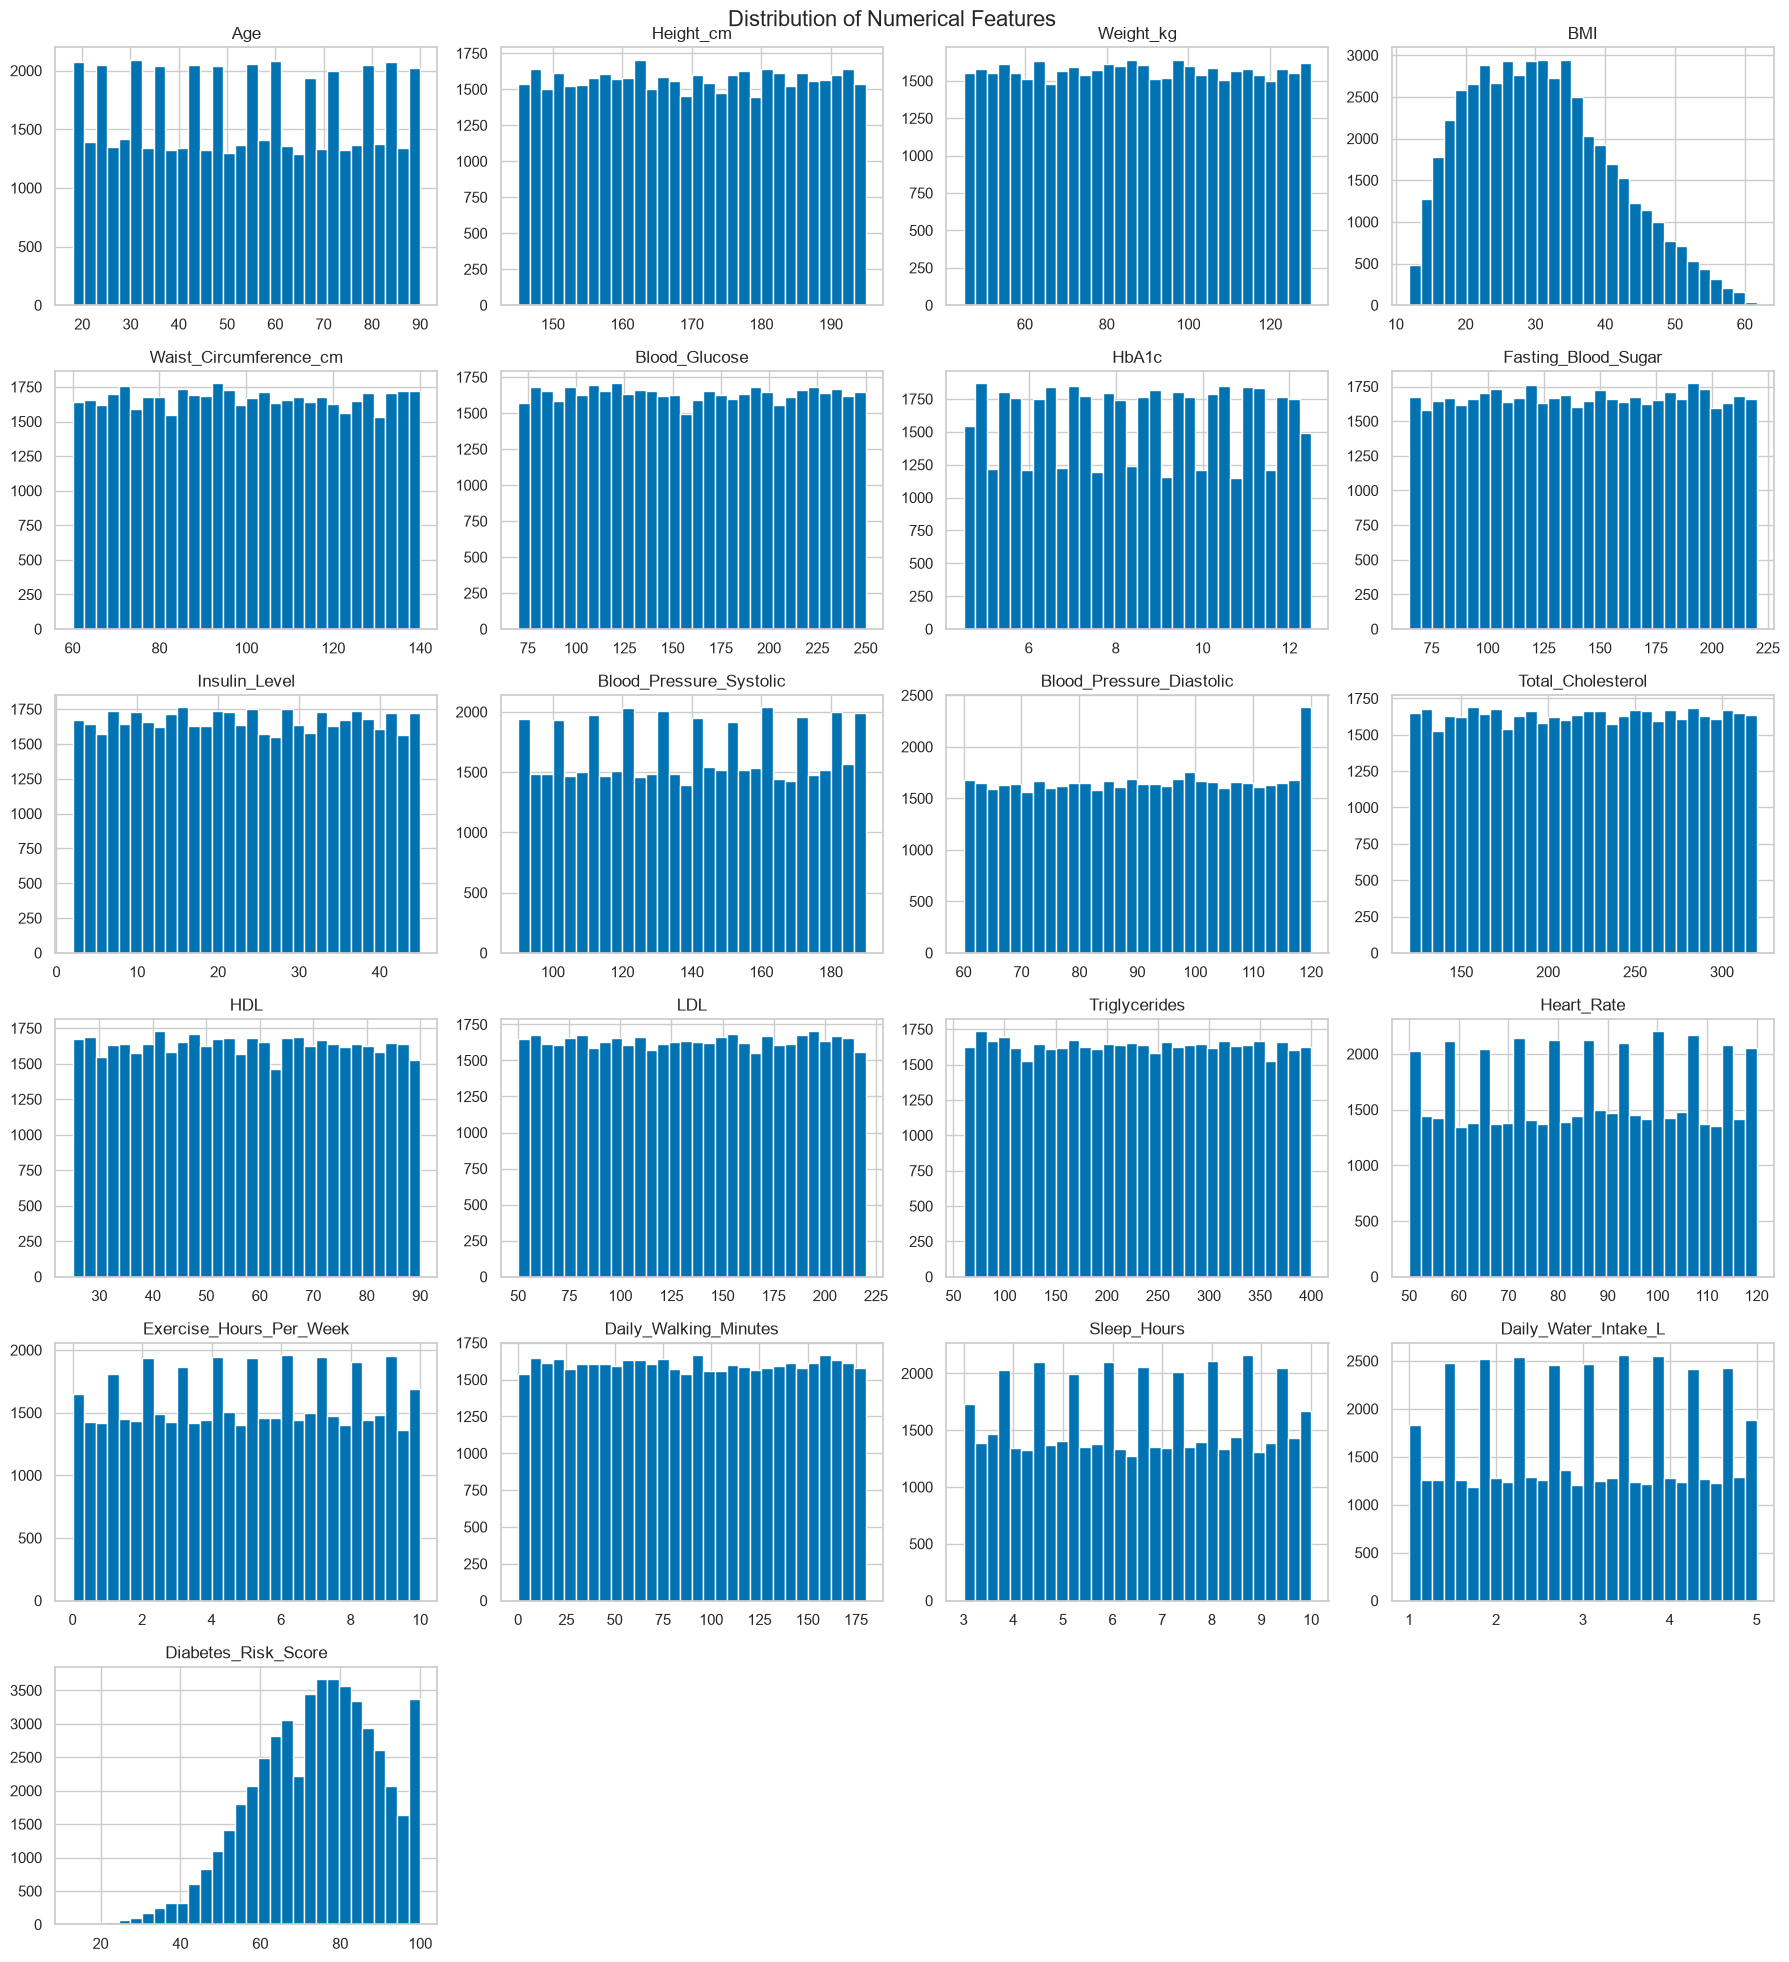

In [4]:
# Numerical feature distributions

numerical_features = df.select_dtypes(
    include=np.number
).columns.tolist()

# Exclude ID and target
numerical_features = [
    col for col in numerical_features
    if col not in ["Patient_ID", TARGET]
]

print("Number of numerical features:", len(numerical_features))

df[numerical_features].hist(
    bins=30,
    figsize=(18, 20),
    layout=(-1, 4)
)

plt.suptitle(
    "Distribution of Numerical Features",
    fontsize=16
)

plt.tight_layout()
plt.show()

### A3. Numerical Feature Distribution — Observation

The dataset contains 21 numerical features with varied distribution patterns. Most features are broadly distributed across their ranges, while `BMI` shows a noticeable right-skew and `Diabetes_Risk_Score` is more concentrated toward higher values; several other features show repeated peaks across their ranges.

## A2. Categorical Feature Distributions

Categorical features are analysed using count plots to understand the frequency of their different categories and identify dominant or less frequent groups.

Number of categorical features: 19


C:\Users\HP\AppData\Local\Temp\ipykernel_20552\2193812261.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(


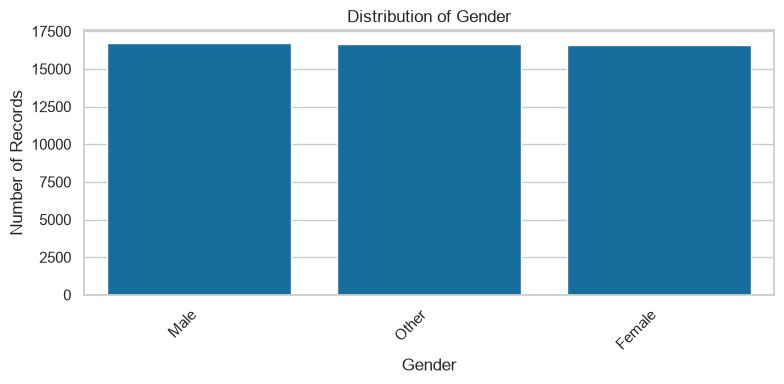

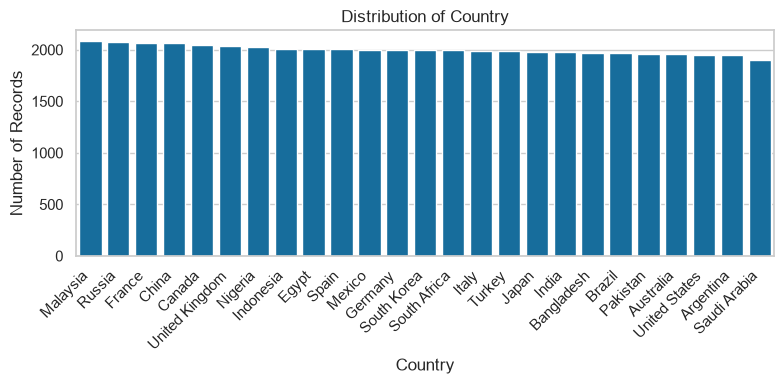

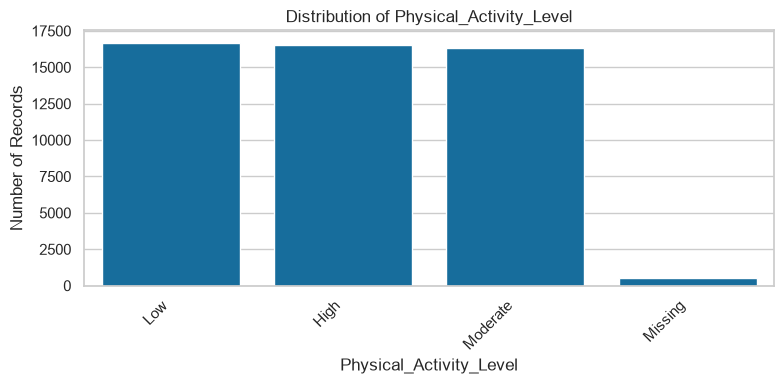

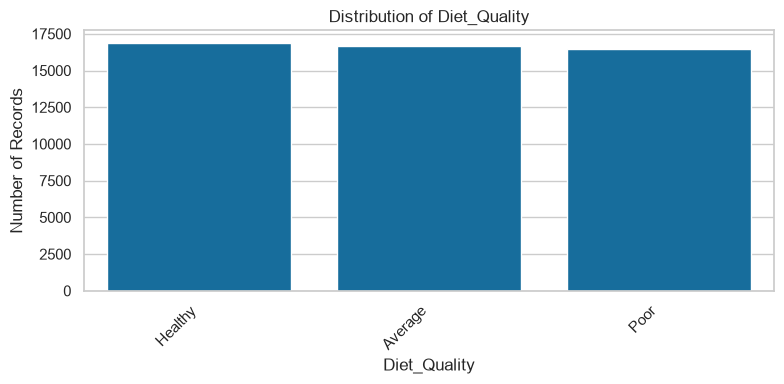

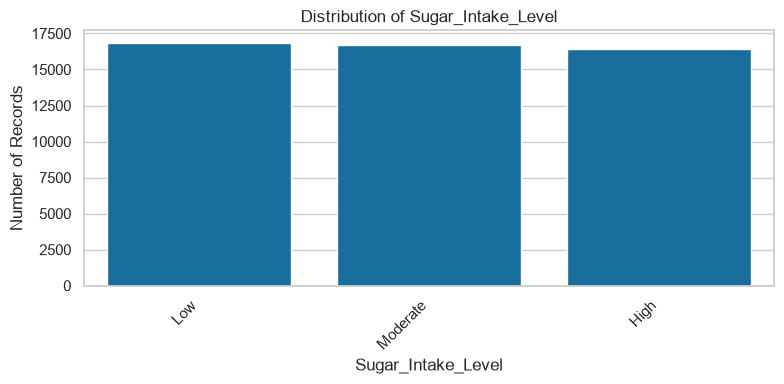

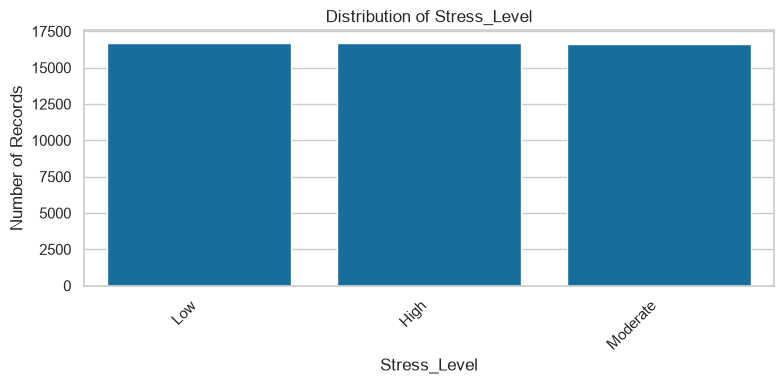

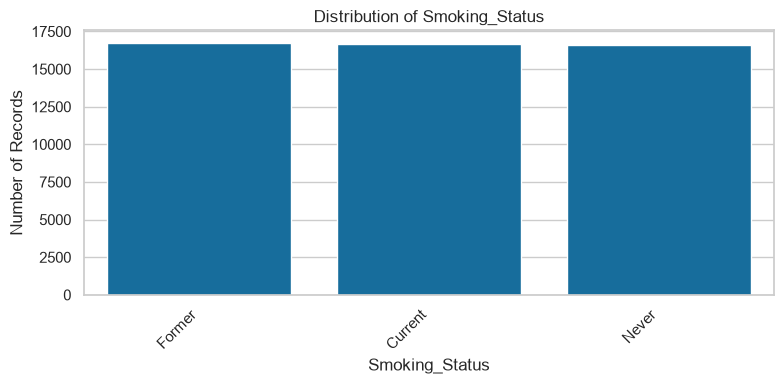

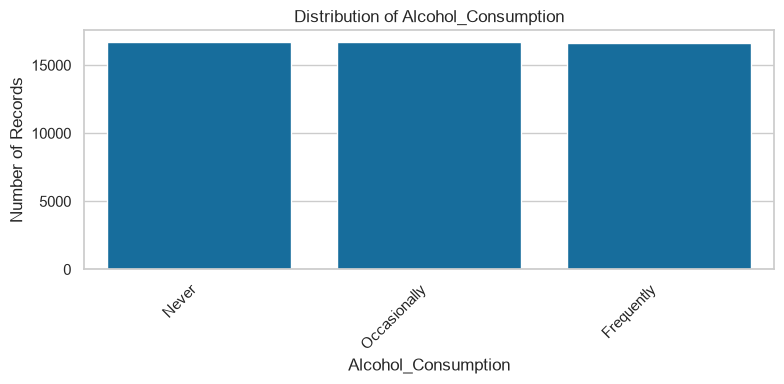

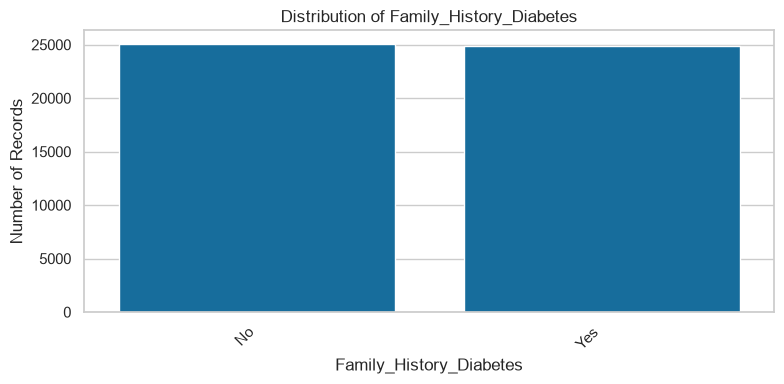

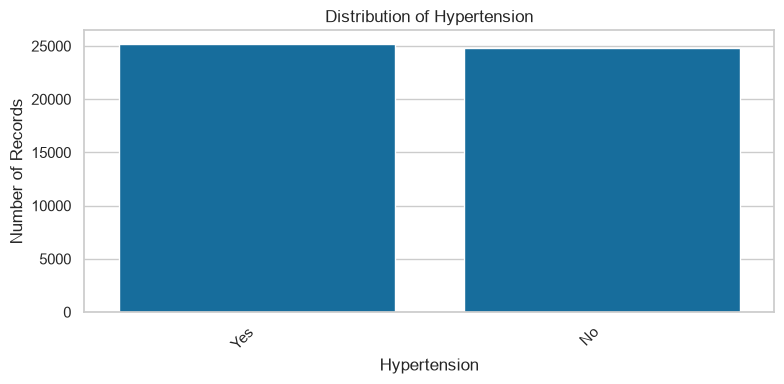

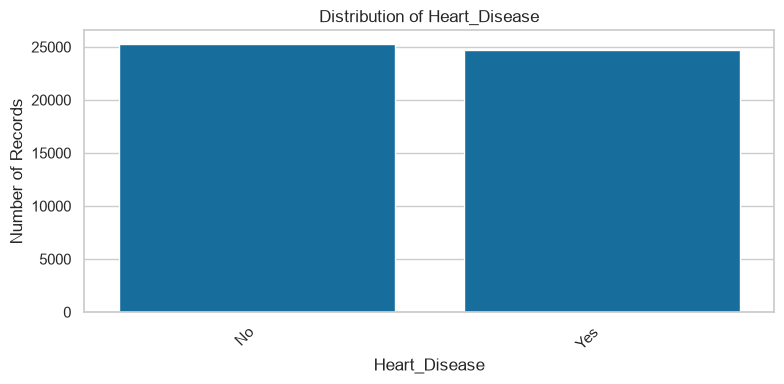

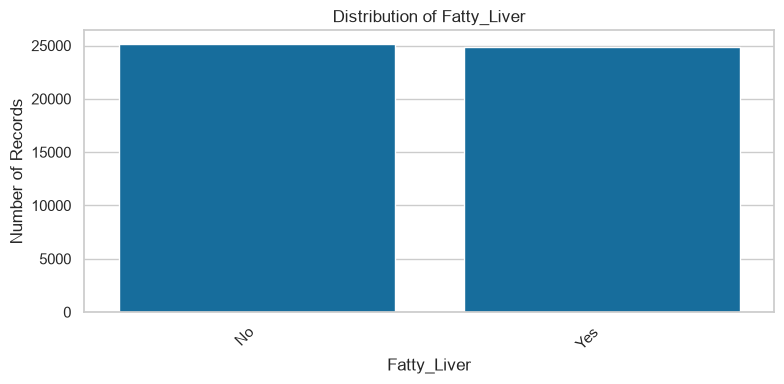

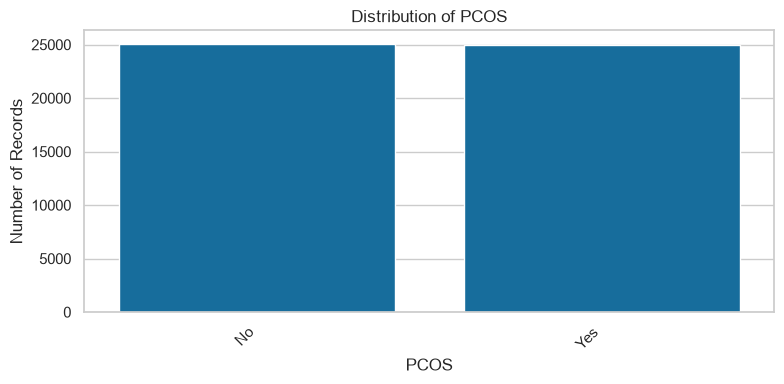

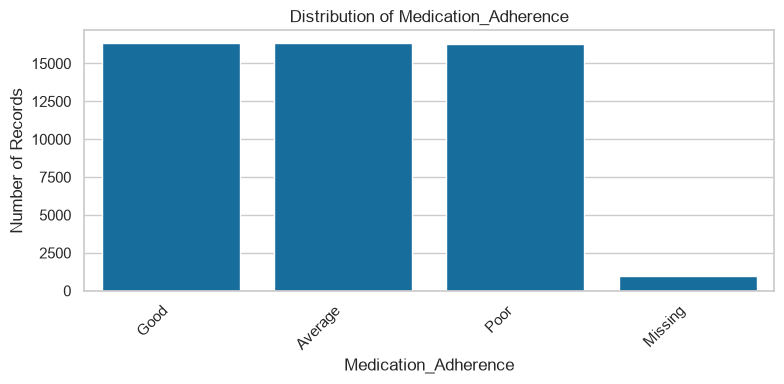

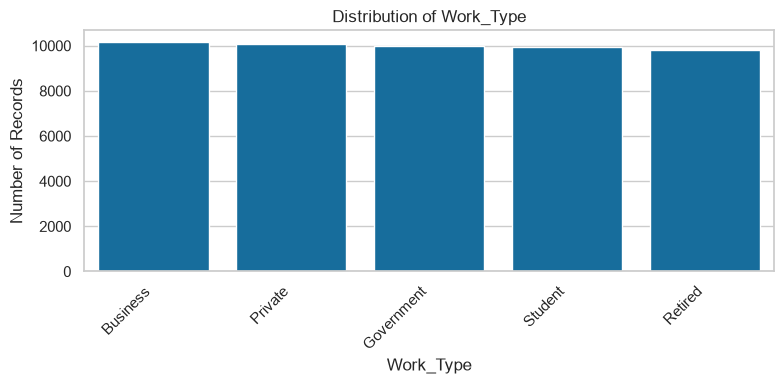

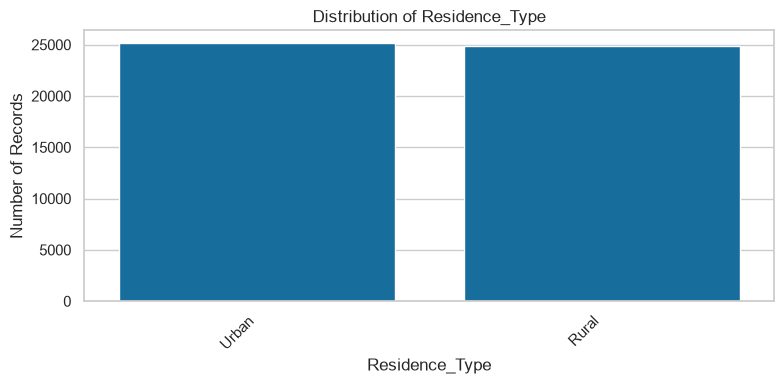

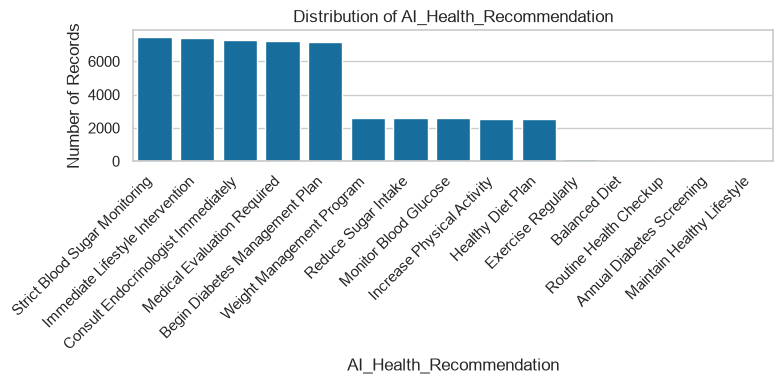

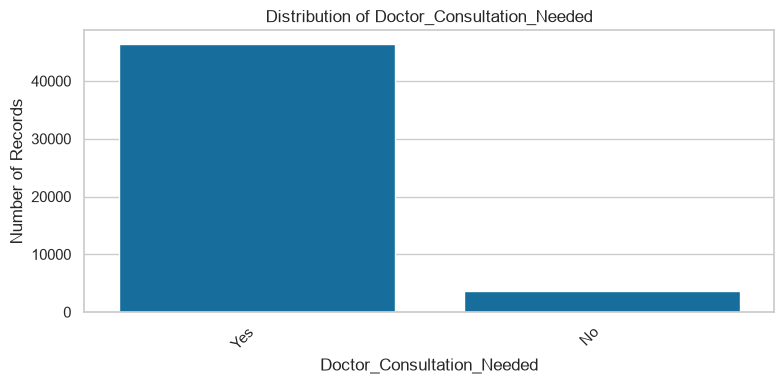

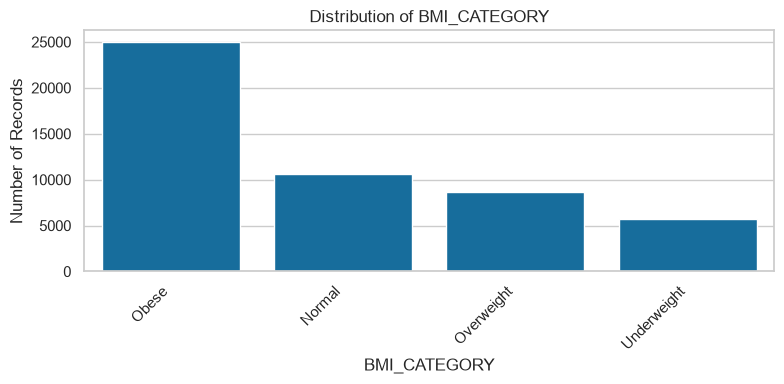

In [5]:
# Categorical feature distributions

categorical_features = df.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

# Remove target variable
categorical_features = [
    col for col in categorical_features
    if col != TARGET
]

print("Number of categorical features:", len(categorical_features))

for feature in categorical_features:

    plot_data = df[feature].astype("string").fillna("Missing")

    plt.figure(figsize=(8, 4))

    sns.countplot(
        x=plot_data,
        order=plot_data.value_counts().index
    )

    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Number of Records")
    plt.xticks(rotation=45, ha="right")

    plt.tight_layout()
    plt.show()

### A3. Categorical Feature Distribution — Observation

The categorical features show different category frequencies across the dataset. Most variables have reasonably distributed categories, while a few features show noticeable dominance of certain categories and some missing values. These differences will be considered during categorical encoding and preprocessing.

## A2. Correlation Heatmap

The correlation heatmap is used to examine the relationships among the numerical features in the dataset.

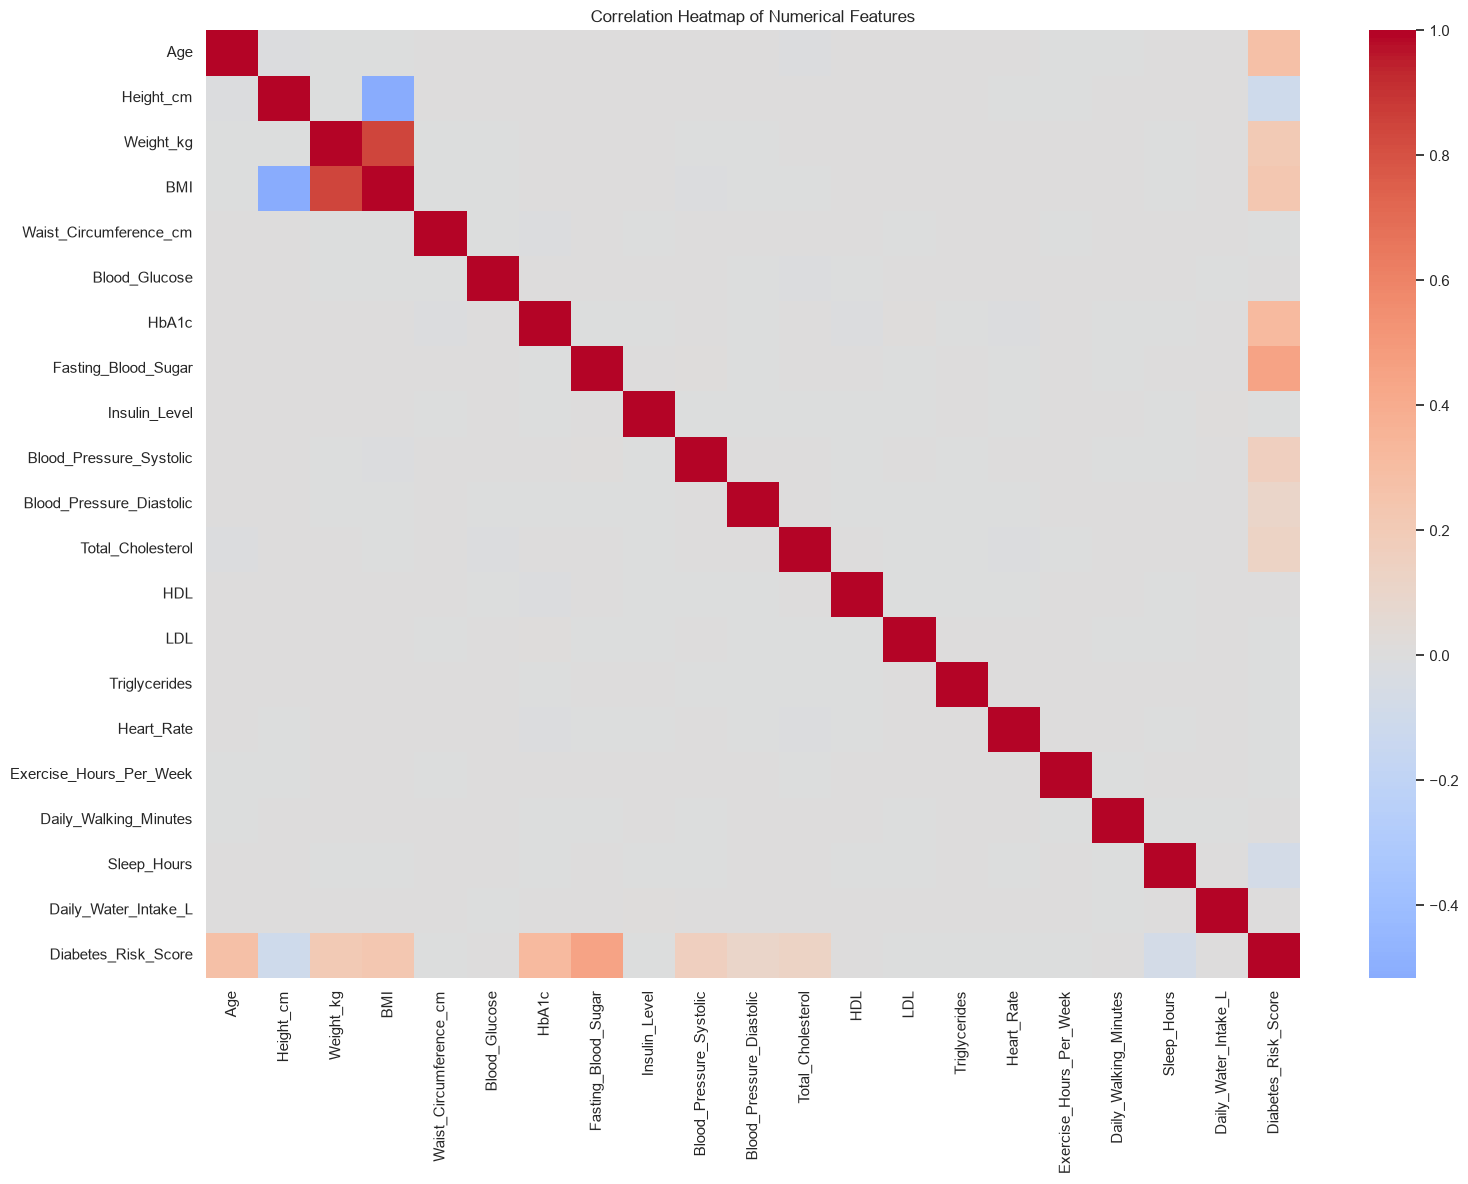

In [6]:
# Correlation heatmap

correlation_matrix = df[numerical_features].corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

### A3. Correlation Heatmap — Observation

The heatmap shows that most numerical features have relatively weak correlations with each other. Stronger positive relationships are observed between `Height_cm`–`Weight_kg`, `Weight_kg`–`BMI`, and `BMI`–`Waist_Circumference_cm`, indicating some related measurements among the health and body-composition features.

## A2. Feature-Target Relationships

Scatter plots are used to examine the relationship between selected numerical features and the diabetes risk classes.

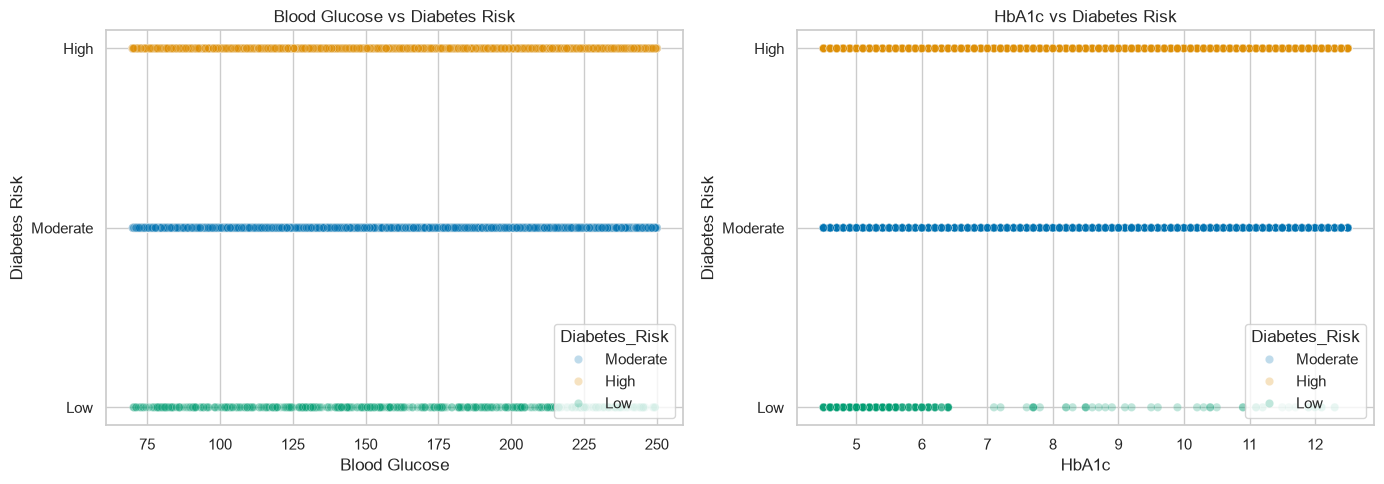

In [7]:
# Scatter plots: numerical features vs diabetes risk

risk_order = {
    "Low": 0,
    "Moderate": 1,
    "High": 2
}

df["Diabetes_Risk_Code"] = df[TARGET].map(risk_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Blood Glucose vs Diabetes Risk
sns.scatterplot(
    data=df,
    x="Blood_Glucose",
    y="Diabetes_Risk_Code",
    hue=TARGET,
    alpha=0.25,
    ax=axes[0]
)

axes[0].set_title("Blood Glucose vs Diabetes Risk")
axes[0].set_xlabel("Blood Glucose")
axes[0].set_ylabel("Diabetes Risk")
axes[0].set_yticks([0, 1, 2])
axes[0].set_yticklabels(["Low", "Moderate", "High"])

# HbA1c vs Diabetes Risk
sns.scatterplot(
    data=df,
    x="HbA1c",
    y="Diabetes_Risk_Code",
    hue=TARGET,
    alpha=0.25,
    ax=axes[1]
)

axes[1].set_title("HbA1c vs Diabetes Risk")
axes[1].set_xlabel("HbA1c")
axes[1].set_ylabel("Diabetes Risk")
axes[1].set_yticks([0, 1, 2])
axes[1].set_yticklabels(["Low", "Moderate", "High"])

plt.tight_layout()
plt.show()


### A3. Feature-Target Relationship — Observation

The scatter plots show considerable overlap between the diabetes-risk classes for both `Blood_Glucose` and `HbA1c`. Although the features vary across the risk levels, neither plot shows a clear separation of the classes based on a single feature alone.

## B1. Data Cleaning

The dataset is checked for missing values, duplicate records, outliers, and potential target leakage before model training.

Missing values are handled during the preprocessing pipeline using training-data statistics. Duplicate records are checked to identify repeated observations, while numerical outliers are examined using the IQR method.

Potential target leakage is also investigated to ensure that variables containing information derived from the target are not provided to the classification models.

In [8]:
# Check missing values and duplicate records

print("Missing values:")
display(
    df.isnull().sum().to_frame("Missing Count")
)

print("\nTotal missing values:", df.isnull().sum().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Missing values:


,Missing Count
Patient_ID,0
Age,497
Gender,0
Country,0
Height_cm,2945
Weight_kg,2962
BMI,0
Waist_Circumference_cm,0
Blood_Glucose,959
HbA1c,1974



Total missing values: 20810

Duplicate rows: 0


In [9]:
# Check potentially derived categorical features

for col in [
    "AI_Health_Recommendation",
    "Doctor_Consultation_Needed"
]:
    print(f"\n===== {col} =====")

    display(
        pd.crosstab(
            df[col],
            df["Diabetes_Risk"],
            normalize="index"
        ).round(3)
    )


===== AI_Health_Recommendation =====


Diabetes_Risk,High,Low,Moderate
AI_Health_Recommendation,,,
Annual Diabetes Screening,0.0,1.0,0.0
Balanced Diet,0.0,1.0,0.0
Begin Diabetes Management Plan,1.0,0.0,0.0
Consult Endocrinologist Immediately,1.0,0.0,0.0
Exercise Regularly,0.0,1.0,0.0
Healthy Diet Plan,0.0,0.0,1.0
Immediate Lifestyle Intervention,1.0,0.0,0.0
Increase Physical Activity,0.0,0.0,1.0
Maintain Healthy Lifestyle,0.0,1.0,0.0



===== Doctor_Consultation_Needed =====


Diabetes_Risk,High,Low,Moderate
Doctor_Consultation_Needed,,,
No,0.000,0.117,0.883
Yes,0.788,0.001,0.211


In [10]:
# Investigate potentially target-derived features

print("Diabetes_Risk_Score by target class:")

display(
    df.groupby("Diabetes_Risk")["Diabetes_Risk_Score"]
      .agg(["min", "max", "mean", "median", "std", "count"])
)

print("\nRisk score vs target:")

display(
    pd.crosstab(
        pd.cut(df["Diabetes_Risk_Score"], bins=10),
        df["Diabetes_Risk"]
    )
)

Diabetes_Risk_Score by target class:


,min,max,mean,median,std,count
Diabetes_Risk,,,,,,
High,65,100,81.409122,81.0,10.159132,36593
Low,13,34,29.236170,30.0,4.302225,470
Moderate,35,64,54.838912,56.0,7.248303,12937



Risk score vs target:


Diabetes_Risk,High,Low,Moderate
Diabetes_Risk_Score,,,
"(12.913, 21.7]",0,30,0
"(21.7, 30.4]",0,207,0
"(30.4, 39.1]",0,233,509
"(39.1, 47.8]",0,0,1750
"(47.8, 56.5]",0,0,4310
"(56.5, 65.2]",1007,0,6368
"(65.2, 73.9]",8708,0,0
"(73.9, 82.6]",10897,0,0
"(82.6, 91.3]",8898,0,0


In [11]:
# Treat the detected BMI outliers using IQR capping

col = "BMI"

Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df[col] = df[col].clip(lower=lower, upper=upper)

print("Outliers treated for:", col)

Outliers treated for: BMI


### B1. Data Cleaning — Observation

The dataset contains missing values but no duplicate rows. Numerical outliers were examined using the IQR method, and the detected BMI outliers were treated using IQR capping.

The leakage investigation showed that `Diabetes_Risk_Score` provides a near-direct representation of the target classes. `AI_Health_Recommendation` and `Doctor_Consultation_Needed` are also strongly associated with the target and may contain downstream risk-assessment information. These variables will therefore be excluded from the model features.

## B3. Feature Engineering

A new `Pulse_Pressure` feature is created by subtracting diastolic blood pressure from systolic blood pressure.

This engineered feature represents the difference between the two blood-pressure measurements and provides an additional numerical representation of blood-pressure characteristics that may be useful for classification.

In [12]:
# Create an engineered feature

df["Pulse_Pressure"] = (
    df["Blood_Pressure_Systolic"]
    - df["Blood_Pressure_Diastolic"]
)

print("Feature engineered successfully.")

display(
    df[
        [
            "Blood_Pressure_Systolic",
            "Blood_Pressure_Diastolic",
            "Pulse_Pressure"
        ]
    ].head()
)

Feature engineered successfully.


,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Pulse_Pressure
0,94,61,33
1,148,100,48
2,101,108,-7
3,120,63,57
4,190,90,100


## B2. Feature Preparation and Train-Test Split

The target variable is separated from the predictor variables before model training.

Identifier, target-derived, and EDA-only variables are excluded from the model inputs. The remaining dataset is divided into training and testing sets using stratified sampling.

Numerical features are imputed and scaled, while categorical features are imputed and one-hot encoded. The preprocessing transformations are fitted only on the training data and then applied to the test data.

In [13]:
# Separate features and target

X = df.drop(
    columns=[
        TARGET,
        "Patient_ID",
        "Diabetes_Risk_Code",
        "Diabetes_Risk_Score",
        "AI_Health_Recommendation",
        "Doctor_Consultation_Needed"
    ]
)

y = df[TARGET]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (50000, 38)
Target shape: (50000,)


In [14]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=GLOBAL_SEED,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

Training set: (40000, 38)
Testing set : (10000, 38)


In [15]:


# Identify numerical and categorical features

num_features = X_train.select_dtypes(
    include=np.number
).columns.tolist()

cat_features = X_train.select_dtypes(
    include=["object", "str", "string", "category", "bool"]
).columns.tolist()

print("Number of numerical features:", len(num_features))
print("Number of categorical features:", len(cat_features))

# Numerical preprocessing

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

# Combine preprocessing

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features)
])

# Fit preprocessing only on training data

X_train_processed = preprocessor.fit_transform(X_train)

# Apply the fitted preprocessing to test data

X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape :", X_test_processed.shape)

Number of numerical features: 21
Number of categorical features: 17
Processed training shape: (40000, 91)
Processed testing shape : (10000, 91)


### B2. Feature Preparation — Observation

The dataset was divided into training and testing sets using stratified sampling, resulting in 40,000 training records and 10,000 testing records. The 38 model features consist of 21 numerical and 17 categorical features. Numerical features were median-imputed and standardized, while categorical features were mode-imputed and one-hot encoded. The preprocessing pipeline was fitted only on the training data and then applied to the test data, resulting in 91 processed features.

## D1. Logistic Regression

Logistic Regression is used as a baseline classification model for predicting the `Diabetes_Risk` class.

The model is trained using the preprocessed training data and evaluated on the unseen test data using Accuracy, weighted F1-score, and a confusion matrix.


In [16]:

# Create and train the Logistic Regression model

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=GLOBAL_SEED
)

logistic_model.fit(
    X_train_processed,
    y_train
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

### Model Evaluation

In [17]:


# Generate predictions
y_pred_logistic = logistic_model.predict(
    X_test_processed
)

# Generate probability predictions for ROC-AUC
y_proba_logistic = logistic_model.predict_proba(
    X_test_processed
)

# Calculate evaluation metrics
logistic_accuracy = accuracy_score(
    y_test,
    y_pred_logistic
)

logistic_precision = precision_score(
    y_test,
    y_pred_logistic,
    average="weighted"
)

logistic_recall = recall_score(
    y_test,
    y_pred_logistic,
    average="weighted"
)

logistic_f1 = f1_score(
    y_test,
    y_pred_logistic,
    average="weighted"
)

logistic_roc_auc = roc_auc_score(
    y_test,
    y_proba_logistic,
    multi_class="ovr",
    average="weighted"
)

print("Accuracy:", logistic_accuracy)
print("Weighted Precision:", logistic_precision)
print("Weighted Recall:", logistic_recall)
print("Weighted F1:", logistic_f1)
print("Weighted ROC-AUC:", logistic_roc_auc)

Accuracy: 0.8863
Weighted Precision: 0.8839345555100819
Weighted Recall: 0.8863
Weighted F1: 0.8846231483970151
Weighted ROC-AUC: 0.9543942957527146


### Result Storage

In [18]:


# Locate the ML-301 repository root
data_path = next(
    (
        parent / "data" / "diabetes_risk_prediction_dataset.csv"
        for parent in (Path.cwd(), *Path.cwd().parents)
        if (parent / "data" / "diabetes_risk_prediction_dataset.csv").exists()
    ),
    None,
)

if data_path is None:
    raise FileNotFoundError(
        "Could not locate the ML-301 repository."
    )

# Store all classification metrics in the repository-level results folder
results_dir = data_path.parents[1] / "results" / "classification_results"
results_dir.mkdir(parents=True, exist_ok=True)

print("Results directory:", results_dir)

Results directory: c:\Users\HP\Documents\ML-301\results\classification_results


In [19]:

# -------------------------------------------------------
# Classification results directory
# -------------------------------------------------------
results_dir = Path(
    r"C:\Users\HP\Documents\ML-301\results\classification_results"
)

results_dir.mkdir(parents=True, exist_ok=True)

# -------------------------------------------------------
# Store Logistic Regression evaluation metrics
# -------------------------------------------------------
logistic_results = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Accuracy": [logistic_accuracy],
    "Precision_weighted": [logistic_precision],
    "Recall_weighted": [logistic_recall],
    "F1_weighted": [logistic_f1],
    "ROC_AUC": [logistic_roc_auc]
})

# -------------------------------------------------------
# Save metrics
# -------------------------------------------------------
logistic_file = (
    results_dir / "01_logistic_regression.csv"
)

logistic_results.to_csv(
    logistic_file,
    index=False
)

# -------------------------------------------------------
# Verify
# -------------------------------------------------------
print("Logistic Regression metrics saved successfully.")
print("File:", logistic_file)

display(
    pd.read_csv(logistic_file)
)

Logistic Regression metrics saved successfully.
File: C:\Users\HP\Documents\ML-301\results\classification_results\01_logistic_regression.csv


,Model,Accuracy,Precision_weighted,Recall_weighted,F1_weighted,ROC_AUC
0,Logistic Regression,0.8863,0.883935,0.8863,0.884623,0.954394


### D1. Logistic Regression — Observation

Logistic Regression achieved an accuracy of 88.63% and a weighted F1-score of 88.46% on the test set. The confusion matrix shows that most High-risk and Moderate-risk samples were classified correctly. The Low-risk class has fewer observations, and some Low-risk and Moderate-risk samples were classified into neighboring risk categories. These results provide a baseline for comparison with the remaining classification algorithms.

## D1. K-Nearest Neighbors (KNN)

K-Nearest Neighbors (KNN) is a distance-based classification algorithm that predicts the class of a sample using the classes of its nearest training samples.

The preprocessed features are used as input to the KNN classifier. Since KNN is sensitive to feature scale, the numerical features are standardized during preprocessing.

### Model Training

The K-Nearest Neighbors (KNN) classifier is trained using the preprocessed training data. A value of `k = 5` is used as the initial number of nearest neighbors.

In [20]:

# Create and train the KNN model
knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(
    X_train_processed,
    y_train
)

print("KNN model trained successfully.")

KNN model trained successfully.


### Model Evaluation

Predictions are generated for the unseen test data. The KNN classifier is evaluated using Accuracy, weighted Precision, weighted Recall, weighted F1-score, and ROC-AUC using the One-vs-Rest strategy.


In [21]:
# Generate predictions
y_pred_knn = knn_model.predict(
    X_test_processed
)

# Generate probability predictions for ROC-AUC
y_proba_knn = knn_model.predict_proba(
    X_test_processed
)

# Calculate evaluation metrics
knn_accuracy = accuracy_score(
    y_test,
    y_pred_knn
)

knn_precision = precision_score(
    y_test,
    y_pred_knn,
    average="weighted"
)

knn_recall = recall_score(
    y_test,
    y_pred_knn,
    average="weighted"
)

knn_f1 = f1_score(
    y_test,
    y_pred_knn,
    average="weighted"
)

knn_roc_auc = roc_auc_score(
    y_test,
    y_proba_knn,
    multi_class="ovr",
    average="weighted"
)

print("Accuracy:", knn_accuracy)
print("Weighted Precision:", knn_precision)
print("Weighted Recall:", knn_recall)
print("Weighted F1:", knn_f1)
print("Weighted ROC-AUC:", knn_roc_auc)

Accuracy: 0.7929
Weighted Precision: 0.7750495070394572
Weighted Recall: 0.7929
Weighted F1: 0.7690838387208268
Weighted ROC-AUC: 0.821778364501003


### Result Storage

The KNN evaluation metrics are stored in a CSV file for use in the final classification comparison.

In [22]:
# Store KNN evaluation metrics
knn_results = pd.DataFrame({
    "Model": ["KNN"],
    "Accuracy": [knn_accuracy],
    "Precision_weighted": [knn_precision],
    "Recall_weighted": [knn_recall],
    "F1_weighted": [knn_f1],
    "ROC_AUC": [knn_roc_auc]
})

# Save metrics to the classification results directory
knn_file = results_dir / "02_knn_classifier.csv"

knn_results.to_csv(
    knn_file,
    index=False
)

print("KNN metrics saved successfully.")
print("File:", knn_file)

display(pd.read_csv(knn_file))

KNN metrics saved successfully.
File: C:\Users\HP\Documents\ML-301\results\classification_results\02_knn_classifier.csv


,Model,Accuracy,Precision_weighted,Recall_weighted,F1_weighted,ROC_AUC
0,KNN,0.7929,0.77505,0.7929,0.769084,0.821778


### Confusion Matrix

The confusion matrix shows the actual and predicted class distribution for the KNN classifier on the unseen test data.

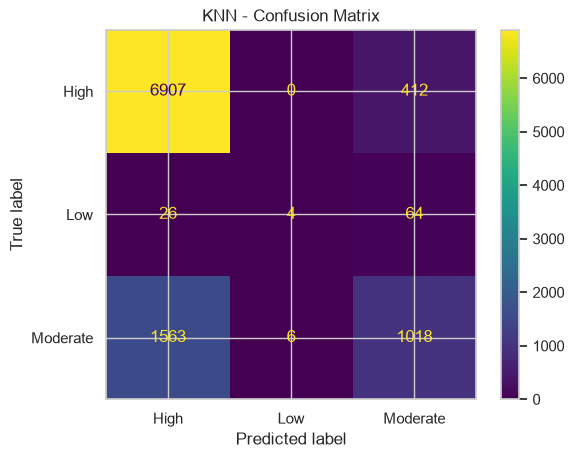

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create confusion matrix
cm_knn = confusion_matrix(
    y_test,
    y_pred_knn
)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_knn,
    display_labels=knn_model.classes_
)

disp.plot()

plt.title("KNN - Confusion Matrix")
plt.show()

### D1. KNN — Observation

KNN achieved an accuracy of 79.29% and a weighted F1-score of 76.91% on the unseen test set. The weighted ROC-AUC was 82.18%. The confusion matrix shows that most High-risk samples were classified correctly, while more misclassifications occurred between the Moderate-risk and High-risk classes. The Low-risk class has relatively few samples, which is reflected in the smaller number of correct predictions for this class. These results provide a baseline for comparing KNN with the other Part-A classification algorithms.

## D1. Gaussian Naive Bayes

Gaussian Naive Bayes is a probabilistic classification algorithm based on Bayes' theorem. It assumes that the numerical features are conditionally independent within each class and models their distributions using a Gaussian (normal) distribution.

The Gaussian Naive Bayes classifier is trained using the preprocessed training data and evaluated on the unseen test data using Accuracy, weighted Precision, weighted Recall, weighted F1-score, and ROC-AUC.

In [24]:
# Create and train the Gaussian Naive Bayes model
gnb_model = GaussianNB()

gnb_model.fit(
    X_train_processed,
    y_train
)

print("Gaussian Naive Bayes model trained successfully.")

Gaussian Naive Bayes model trained successfully.


In [25]:
# Generate predictions
y_pred_gnb = gnb_model.predict(
    X_test_processed
)

# Generate probability predictions for ROC-AUC
y_proba_gnb = gnb_model.predict_proba(
    X_test_processed
)

# Calculate evaluation metrics
gnb_accuracy = accuracy_score(
    y_test,
    y_pred_gnb
)

gnb_precision = precision_score(
    y_test,
    y_pred_gnb,
    average="weighted"
)

gnb_recall = recall_score(
    y_test,
    y_pred_gnb,
    average="weighted"
)

gnb_f1 = f1_score(
    y_test,
    y_pred_gnb,
    average="weighted"
)

gnb_roc_auc = roc_auc_score(
    y_test,
    y_proba_gnb,
    multi_class="ovr",
    average="weighted"
)

print("Accuracy:", gnb_accuracy)
print("Weighted Precision:", gnb_precision)
print("Weighted Recall:", gnb_recall)
print("Weighted F1:", gnb_f1)
print("Weighted ROC-AUC:", gnb_roc_auc)

Accuracy: 0.8084
Weighted Precision: 0.8102319331694998
Weighted Recall: 0.8084
Weighted F1: 0.8091172226056882
Weighted ROC-AUC: 0.879713352522011


In [26]:
# Store Gaussian Naive Bayes evaluation metrics
gnb_results = pd.DataFrame({
    "Model": ["Gaussian Naive Bayes"],
    "Accuracy": [gnb_accuracy],
    "Precision_weighted": [gnb_precision],
    "Recall_weighted": [gnb_recall],
    "F1_weighted": [gnb_f1],
    "ROC_AUC": [gnb_roc_auc]
})

# Save metrics to the classification results directory
gnb_file = results_dir / "03_gaussian_naive_bayes.csv"

gnb_results.to_csv(
    gnb_file,
    index=False
)

print("Gaussian Naive Bayes metrics saved successfully.")
print("File:", gnb_file)

display(pd.read_csv(gnb_file))

Gaussian Naive Bayes metrics saved successfully.
File: C:\Users\HP\Documents\ML-301\results\classification_results\03_gaussian_naive_bayes.csv


,Model,Accuracy,Precision_weighted,Recall_weighted,F1_weighted,ROC_AUC
0,Gaussian Naive Bayes,0.8084,0.810232,0.8084,0.809117,0.879713


### Confusion Matrix

The confusion matrix shows the actual and predicted class distribution for the Gaussian Naive Bayes classifier on the unseen test data.

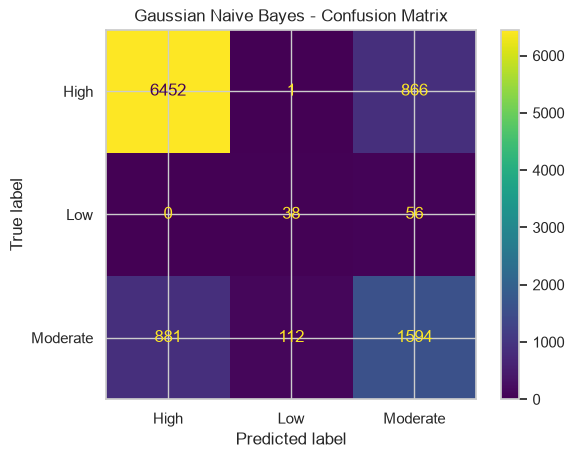

In [27]:
# Create confusion matrix
cm_gnb = confusion_matrix(
    y_test,
    y_pred_gnb
)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_gnb,
    display_labels=gnb_model.classes_
)

disp.plot()

plt.title("Gaussian Naive Bayes - Confusion Matrix")
plt.show()

### D1. Gaussian Naive Bayes — Observation

Gaussian Naive Bayes achieved an accuracy of 80.84% and a weighted F1-score of 80.91% on the unseen test set. The weighted ROC-AUC was 87.97%. The confusion matrix shows that most High-risk samples were classified correctly, while a noticeable number of Moderate-risk samples were classified as High-risk. The Low-risk class has relatively few samples, resulting in fewer correct predictions for this class. These results provide a baseline for comparing Gaussian Naive Bayes with the remaining Part-A classification algorithms.

## D1. Decision Tree Classifier

Decision Tree is a tree-based classification algorithm that recursively splits the data based on feature values to make class predictions.

The Decision Tree classifier is trained using the preprocessed training data and evaluated on the unseen test data using Accuracy, weighted Precision, weighted Recall, weighted F1-score, and ROC-AUC.

In [28]:
# Create and train the Decision Tree model
dt_model = DecisionTreeClassifier(
    random_state=GLOBAL_SEED
)

dt_model.fit(
    X_train_processed,
    y_train
)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


### Model Evaluation

Predictions are generated for the unseen test data. The Decision Tree classifier is evaluated using Accuracy, weighted Precision, weighted Recall, weighted F1-score, and ROC-AUC using the One-vs-Rest strategy.

In [29]:
# Generate predictions
y_pred_dt = dt_model.predict(
    X_test_processed
)

# Generate probability predictions for ROC-AUC
y_proba_dt = dt_model.predict_proba(
    X_test_processed
)

# Calculate evaluation metrics
dt_accuracy = accuracy_score(
    y_test,
    y_pred_dt
)

dt_precision = precision_score(
    y_test,
    y_pred_dt,
    average="weighted"
)

dt_recall = recall_score(
    y_test,
    y_pred_dt,
    average="weighted"
)

dt_f1 = f1_score(
    y_test,
    y_pred_dt,
    average="weighted"
)

dt_roc_auc = roc_auc_score(
    y_test,
    y_proba_dt,
    multi_class="ovr",
    average="weighted"
)

print("Accuracy:", dt_accuracy)
print("Weighted Precision:", dt_precision)
print("Weighted Recall:", dt_recall)
print("Weighted F1:", dt_f1)
print("Weighted ROC-AUC:", dt_roc_auc)

Accuracy: 0.8252
Weighted Precision: 0.8283464843570478
Weighted Recall: 0.8252
Weighted F1: 0.8266776323747194
Weighted ROC-AUC: 0.7948677000316132


In [30]:
# Store Decision Tree evaluation metrics
dt_results = pd.DataFrame({
    "Model": ["Decision Tree"],
    "Accuracy": [dt_accuracy],
    "Precision_weighted": [dt_precision],
    "Recall_weighted": [dt_recall],
    "F1_weighted": [dt_f1],
    "ROC_AUC": [dt_roc_auc]
})

# Save metrics to the classification results directory
dt_file = results_dir / "04_decision_tree_classifier.csv"

dt_results.to_csv(
    dt_file,
    index=False
)

print("Decision Tree metrics saved successfully.")
print("File:", dt_file)

display(pd.read_csv(dt_file))

Decision Tree metrics saved successfully.
File: C:\Users\HP\Documents\ML-301\results\classification_results\04_decision_tree_classifier.csv


,Model,Accuracy,Precision_weighted,Recall_weighted,F1_weighted,ROC_AUC
0,Decision Tree,0.8252,0.828346,0.8252,0.826678,0.794868


### Confusion Matrix

The confusion matrix shows the actual and predicted class distribution for the Decision Tree classifier on the unseen test data.

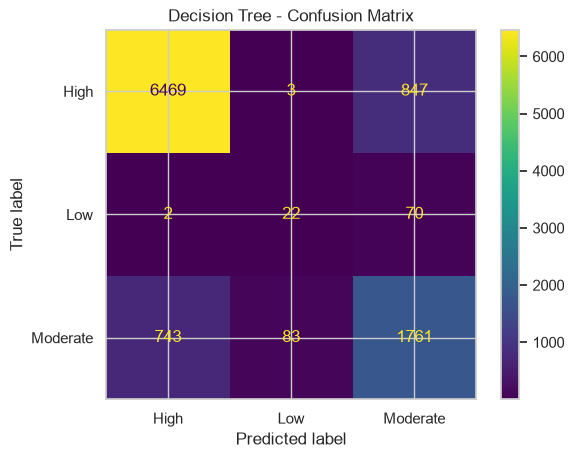

In [31]:
# Create confusion matrix
cm_dt = confusion_matrix(
    y_test,
    y_pred_dt
)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=dt_model.classes_
)

disp.plot()

plt.title("Decision Tree - Confusion Matrix")
plt.show()

### D1. Decision Tree — Observation

Decision Tree achieved an accuracy of 82.52% and a weighted F1-score of 82.67% on the unseen test set. The weighted ROC-AUC was 79.49%. The confusion matrix shows that most High-risk and Moderate-risk samples were classified correctly, while some Moderate-risk samples were classified as High-risk. The Low-risk class has relatively few samples, resulting in fewer correct predictions for this class. These results provide another baseline for comparison with the remaining Part-A classification algorithm, SVC.

## D1. Support Vector Machine (SVC)

Support Vector Classifier (SVC) is a supervised classification algorithm that finds a decision boundary to separate classes in the feature space.

The SVC model is trained using the preprocessed training data and evaluated on the unseen test data using Accuracy, weighted Precision, weighted Recall, weighted F1-score, and ROC-AUC.

In [32]:
# Create and train the SVC model
svc_model = SVC(
    probability=True,
    random_state=GLOBAL_SEED
)

svc_model.fit(
    X_train_processed,
    y_train
)

print("SVC model trained successfully.")

c:\Users\HP\Documents\ML-301\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


SVC model trained successfully.


### Model Evaluation

Predictions are generated for the unseen test data. The SVC model is evaluated using Accuracy, weighted Precision, weighted Recall, weighted F1-score, and ROC-AUC using the One-vs-Rest strategy.

In [33]:
# Generate predictions and probabilities
y_pred_svc = svc_model.predict(X_test_processed)
y_proba_svc = svc_model.predict_proba(X_test_processed)

# Calculate evaluation metrics
svc_accuracy = accuracy_score(y_test, y_pred_svc)

svc_precision = precision_score(
    y_test,
    y_pred_svc,
    average="weighted"
)

svc_recall = recall_score(
    y_test,
    y_pred_svc,
    average="weighted"
)

svc_f1 = f1_score(
    y_test,
    y_pred_svc,
    average="weighted"
)

svc_roc_auc = roc_auc_score(
    y_test,
    y_proba_svc,
    multi_class="ovr",
    average="weighted"
)

print("SVC Results")
print("Accuracy            :", round(svc_accuracy, 4))
print("Precision (weighted):", round(svc_precision, 4))
print("Recall (weighted)   :", round(svc_recall, 4))
print("F1-score (weighted) :", round(svc_f1, 4))
print("ROC-AUC (weighted)  :", round(svc_roc_auc, 4))

SVC Results
Accuracy            : 0.915
Precision (weighted): 0.9154
Recall (weighted)   : 0.915
F1-score (weighted) : 0.9116
ROC-AUC (weighted)  : 0.972


In [36]:
# Store SVC evaluation metrics
svc_results = pd.DataFrame({
    "Model": ["SVC"],
    "Accuracy": [svc_accuracy],
    "Precision_weighted": [svc_precision],
    "Recall_weighted": [svc_recall],
    "F1_weighted": [svc_f1],
    "ROC_AUC": [svc_roc_auc]
})

# Save metrics to the classification results directory
svc_file = results_dir / "05_svc.csv"

svc_results.to_csv(
    svc_file,
    index=False
)

print("SVC metrics saved successfully.")
print("File:", svc_file)

display(pd.read_csv(svc_file))

SVC metrics saved successfully.
File: C:\Users\HP\Documents\ML-301\results\classification_results\05_svc.csv


,Model,Accuracy,Precision_weighted,Recall_weighted,F1_weighted,ROC_AUC
0,SVC,0.915,0.915368,0.915,0.911646,0.971985


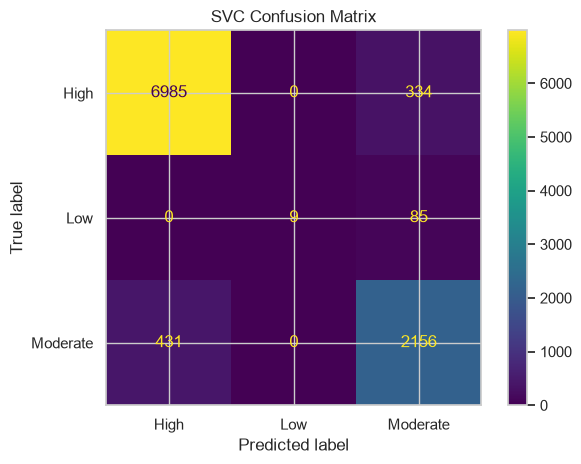

In [34]:
# Confusion matrix
svc_cm = confusion_matrix(y_test, y_pred_svc)

disp = ConfusionMatrixDisplay(
    confusion_matrix=svc_cm,
    display_labels=svc_model.classes_
)

disp.plot()

plt.title("SVC Confusion Matrix")
plt.tight_layout()
plt.show()

### D1. SVC — Observation

SVC achieved an accuracy of 91.50% and a weighted F1-score of 91.16% on the unseen test set. The weighted ROC-AUC was 97.20%. The confusion matrix shows that most High-risk and Moderate-risk samples were classified correctly, with 6,985 High-risk samples and 2,156 Moderate-risk samples correctly predicted. The Low-risk class has relatively few samples, with 9 correctly classified samples and more misclassifications into the Moderate-risk class. Overall, SVC provides a strong baseline for comparison with the other Part-A classification algorithms.

## D2. Part-A Classification Model Comparison

The five Part-A classification algorithms are compared using their evaluation results on the same test set. The comparison table summarizes the performance of each algorithm using Accuracy, weighted Precision, weighted Recall, weighted F1-score, and ROC-AUC.

In [37]:
# Combine Part-A classification results

part_a_results = pd.concat([
    pd.read_csv(results_dir / "01_logistic_regression.csv"),
    pd.read_csv(results_dir / "02_knn_classifier.csv"),
    pd.read_csv(results_dir / "03_gaussian_naive_bayes.csv"),
    pd.read_csv(results_dir / "04_decision_tree_classifier.csv"),
    pd.read_csv(results_dir / "05_svc.csv")
], ignore_index=True)

display(part_a_results.round(4))

,Model,Accuracy,Precision_weighted,Recall_weighted,F1_weighted,ROC_AUC
0,Logistic Regression,0.8863,0.8839,0.8863,0.8846,0.9544
1,KNN,0.7929,0.7750,0.7929,0.7691,0.8218
2,Gaussian Naive Bayes,0.8084,0.8102,0.8084,0.8091,0.8797
3,Decision Tree,0.8252,0.8283,0.8252,0.8267,0.7949
4,SVC,0.9150,0.9154,0.9150,0.9116,0.9720


### D2. Part-A Comparison — Observation

The five Part-A classification algorithms show different levels of performance on the common test set. SVC achieved the highest Accuracy (91.50%), weighted F1-score (91.16%), and ROC-AUC (97.20%) among the five models. Logistic Regression achieved the next strongest overall results, with 88.63% Accuracy, 88.46% weighted F1-score, and 95.44% ROC-AUC.

Decision Tree achieved 82.52% Accuracy and 82.67% weighted F1-score, while Gaussian Naive Bayes achieved 80.84% Accuracy and 80.91% weighted F1-score. KNN produced the lowest Accuracy (79.29%) and weighted F1-score (76.91%) among the Part-A models.

The results indicate that SVC provides the strongest preliminary performance on this test set, while the differences between Accuracy and weighted F1-score should be considered because the target classes are imbalanced. These results will be used as a baseline for comparison with the five Part-B classification algorithms in Review 2.

### Preliminary Best Part-A Classifier

Based on the preliminary comparison, SVC is the best-performing Part-A classifier on the current test set, achieving the highest Accuracy, weighted F1-score, and ROC-AUC among the five algorithms.

SVC achieved 91.50% Accuracy, 91.16% weighted F1-score, and 97.20% weighted ROC-AUC. This is a preliminary selection only; the final model will be determined after evaluating the Part-B algorithms and performing hyperparameter tuning in Review 2.

In [ ]:
# Identify the preliminary best Part-A classifier

best_part_a = part_a_results.loc[
    part_a_results["F1_weighted"].idxmax()
]

print("Preliminary Best Part-A Classifier:", best_part_a["Model"])
print("Accuracy:", round(best_part_a["Accuracy"], 4))
print("Weighted F1:", round(best_part_a["F1_weighted"], 4))
print("ROC-AUC:", round(best_part_a["ROC_AUC"], 4))